# ☀️ TAHMO Solar Radiation Drift Correction — Advanced Colab Notebook

**Goal.** Predict incoming shortwave radiation at 15-minute intervals for the
withheld even months of Year 1 at each TAHMO station, given temperature,
relative humidity, and rainfall for the full year.

**Why this design works.**

1. *Solar radiation is a physical signal.* The dominant driver is the position
   of the sun in the sky, which we can compute exactly from latitude, longitude,
   and timestamp. We use [`pvlib`](https://pvlib-python.readthedocs.io/) to get
   the solar zenith angle, the extraterrestrial irradiance, and the clear-sky
   GHI. These features capture roughly 70–85 % of the variance before any ML.
2. *The residual is weather-driven.* Clouds, humidity, and rain depress the
   actual GHI below the clear-sky envelope. LightGBM, given temperature,
   humidity, and rain along with their lags and rolling statistics, learns this
   atmospheric attenuation residual very efficiently.
3. *Per-station modelling beats one global model.* Each station has its own
   microclimate, terrain shading, and sensor mounting. We train one LightGBM
   per station, with a global LightGBM as a safety net for stations with too
   few training rows.
4. *The leaderboard penalises bias.* The score is `0.5·|MBE| + 0.5·RMSE`. We
   monitor both during cross-validation and apply a small per-station bias
   correction at inference time.
5. *Physical post-processing.* Radiation cannot be negative and must be zero
   when the sun is below the horizon. We enforce both at the end.

**A note on reinforcement learning.** RL is built for sequential
decision-making under reward feedback. This challenge is a stationary
regression problem with a closed-form metric, so RL would be the wrong tool
— it converges slowly, has high variance, and offers no advantage over
gradient boosting on tabular data with strong physical priors. We instead
ensemble LightGBM with CatBoost (different tree-building strategy) via
out-of-fold stacking, which delivers the diversity that ensembles need
without any of the RL overhead.


## 1 · Environment setup (Colab)

Run this once per Colab session. It installs `pvlib`, `lightgbm`, and
`catboost`. Restart the runtime only if Colab complains.

In [1]:
# Colab install. Safe to re-run.
import sys, subprocess

def pip(pkg):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

for p in ["pvlib", "lightgbm", "catboost", "scikit-learn>=1.3"]:
    pip(p)

print("Setup complete.")


Setup complete.


In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pvlib
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

pd.set_option("display.max_columns", 200)
sns.set_context("notebook")
sns.set_style("whitegrid")
print("Imports OK · pvlib", pvlib.__version__, "· lightgbm", lgb.__version__)


Imports OK · pvlib 0.15.1 · lightgbm 4.6.0


In [17]:
SEED = 42
N_FOLDS = 5


## 3 · Load data and auto-detect the schema

The competition file uses slightly different column names across releases
(`station` vs `station_name`, `timestamp` vs `datetime`, and the radiation
target column has been published under several names). We detect them rather
than hard-code, so this notebook will keep working if the organisers rename
anything.

In [18]:
train = pd.read_csv("/content/Train.csv")
test  = pd.read_csv( "/content/Test.csv")

print("Train shape:", train.shape)
print("Test shape :", test.shape)


def first_present(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None

STATION_COL   = first_present(train.columns, ["station", "station_name", "station_id"])
TIMESTAMP_COL = first_present(train.columns, ["timestamp", "datetime", "date_time"])
ID_COL        = first_present(test.columns,  ["ID", "Id", "id"])

# Target column: anything mentioning radiation / shortwave / ghi
target_candidates = [
    c for c in train.columns
    if any(k in c.lower() for k in ["radiation", "shortwave", "ghi", "swd"])
]
TARGET_COL = target_candidates[0] if target_candidates else None

LAT_COL   = first_present(train.columns, ["latitude", "lat"])
LON_COL   = first_present(train.columns, ["longitude", "lon", "lng"])
ELEV_COL  = first_present(train.columns, ["elevation", "altitude", "elev"])
TEMP_COL  = first_present(train.columns, ["temperature (degrees Celsius)", "temperature", "temp"])
RH_COL    = first_present(train.columns, ["relativehumidity (-)", "relative_humidity", "humidity", "rh"])
RAIN_COL  = first_present(train.columns, ["precipitation (mm)", "precipitation", "rainfall", "rain"])

detected = {
    "station"     : STATION_COL,
    "timestamp"   : TIMESTAMP_COL,
    "id"          : ID_COL,
    "target"      : TARGET_COL,
    "latitude"    : LAT_COL,
    "longitude"   : LON_COL,
    "elevation"   : ELEV_COL,
    "temperature" : TEMP_COL,
    "humidity"    : RH_COL,
    "rainfall"    : RAIN_COL,
}
for k, v in detected.items():
    print(f"{k:12s}: {v}")

missing = [k for k, v in detected.items() if v is None]
if missing:
    raise ValueError(f"Could not detect columns: {missing}. Inspect train.columns and fix.")


Train shape: (642175, 13)
Test shape : (683353, 12)
station     : station
timestamp   : timestamp
id          : ID
target      : radiation (W/m2)
latitude    : latitude
longitude   : longitude
elevation   : elevation
temperature : temperature (degrees Celsius)
humidity    : relativehumidity (-)
rainfall    : precipitation (mm)


In [19]:
# Parse timestamps once and sort
for df in (train, test):
    df[TIMESTAMP_COL] = pd.to_datetime(df[TIMESTAMP_COL], errors="coerce")

train = train.sort_values([STATION_COL, TIMESTAMP_COL]).reset_index(drop=True)
test  = test.sort_values([STATION_COL, TIMESTAMP_COL]).reset_index(drop=True)

display(train.head())
display(test.head())


,ID,timestamp,precipitation (mm),radiation (W/m2),relativehumidity (-),temperature (degrees Celsius),station,station_name,country,installation_height,elevation,latitude,longitude
0,b90ca874_2016-01_D3J06S,2016-01-11 10:30:00,0.0,806.0,0.58,20.4,TA00078,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936
1,b90ca874_2016-01_CICFMD,2016-01-11 10:45:00,0.0,612.0,0.58,20.5,TA00078,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936
2,b90ca874_2016-01_7YYUCC,2016-01-11 11:00:00,0.0,775.0,0.55,20.4,TA00078,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936
3,b90ca874_2016-01_GC3UW6,2016-01-11 11:15:00,0.0,379.0,0.56,20.5,TA00078,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936
4,b90ca874_2016-01_DJLS3P,2016-01-11 11:30:00,0.0,405.0,0.58,19.7,TA00078,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936


,ID,timestamp,precipitation (mm),relativehumidity (-),temperature (degrees Celsius),station,station_name,country,installation_height,elevation,latitude,longitude
0,b90ca874_2016-02_R0DXEB,2016-02-01 00:00:00,0.0,0.96,12.7,TA00078,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936
1,b90ca874_2016-02_NC9LCK,2016-02-01 00:15:00,0.0,0.97,12.7,TA00078,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936
2,b90ca874_2016-02_1H20M4,2016-02-01 00:30:00,0.0,0.97,12.6,TA00078,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936
3,b90ca874_2016-02_5J12GN,2016-02-01 00:45:00,0.0,0.99,12.1,TA00078,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936
4,b90ca874_2016-02_3AJGWD,2016-02-01 01:00:00,0.0,1.00,11.9,TA00078,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936


## 4 · Exploratory Data Analysis

The EDA is structured around four questions:

1. **Coverage** — how many stations, how many rows per station, what date
   ranges are in train vs test?
2. **Missingness** — are weather features patchy?
3. **Diurnal and seasonal patterns** — does radiation behave like a clean
   bell curve through the day?
4. **Spatial layout** — where are the stations on the map?


In [20]:
print("Stations in train :", train[STATION_COL].nunique())
print("Stations in test  :", test[STATION_COL].nunique())
print("Train date range  :", train[TIMESTAMP_COL].min(), "→", train[TIMESTAMP_COL].max())
print("Test  date range  :", test[TIMESTAMP_COL].min(),  "→", test[TIMESTAMP_COL].max())

print("\nTrain months :", sorted(train[TIMESTAMP_COL].dt.month.unique()))
print("Test  months :", sorted(test[TIMESTAMP_COL].dt.month.unique()))


Stations in train : 40
Stations in test  : 40
Train date range  : 2016-01-11 10:30:00 → 2020-11-30 23:45:00
Test  date range  : 2016-02-01 00:00:00 → 2020-12-31 23:45:00

Train months : [np.int32(1), np.int32(3), np.int32(5), np.int32(7), np.int32(9), np.int32(11)]
Test  months : [np.int32(2), np.int32(4), np.int32(6), np.int32(8), np.int32(10), np.int32(12)]


In [21]:
# Missing values
print("Train missing (top 15):")
print(train.isna().sum().sort_values(ascending=False).head(15))
print("\nTest missing (top 15):")
print(test.isna().sum().sort_values(ascending=False).head(15))


Train missing (top 15):
ID                               0
timestamp                        0
precipitation (mm)               0
radiation (W/m2)                 0
relativehumidity (-)             0
temperature (degrees Celsius)    0
station                          0
station_name                     0
country                          0
installation_height              0
elevation                        0
latitude                         0
longitude                        0
dtype: int64

Test missing (top 15):
ID                               0
timestamp                        0
precipitation (mm)               0
relativehumidity (-)             0
temperature (degrees Celsius)    0
station                          0
station_name                     0
country                          0
installation_height              0
elevation                        0
latitude                         0
longitude                        0
dtype: int64


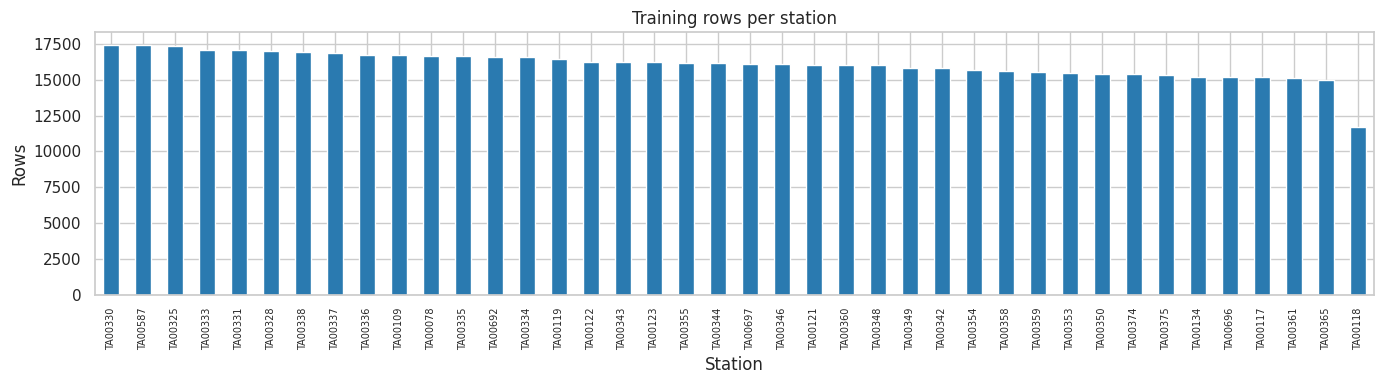

In [22]:
# Rows per station
counts = train[STATION_COL].value_counts().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(14, 4))
counts.plot(kind="bar", ax=ax, color="#2a7ab0")
ax.set_title("Training rows per station")
ax.set_xlabel("Station"); ax.set_ylabel("Rows")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout(); plt.show()


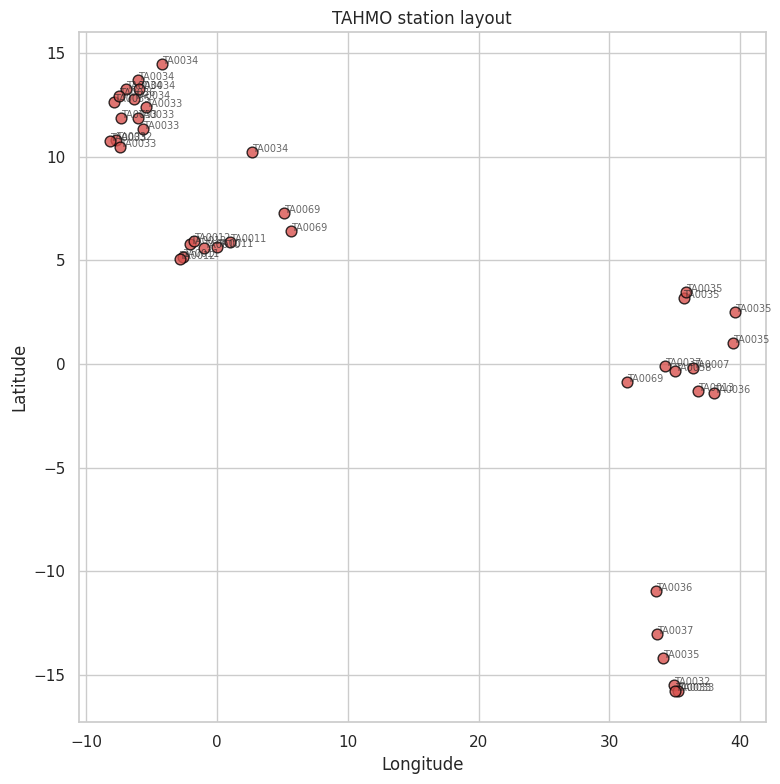

In [23]:
# Spatial map of stations
station_meta = (train
    .groupby(STATION_COL)[[LAT_COL, LON_COL]]
    .first()
    .dropna()
    .reset_index())

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(station_meta[LON_COL], station_meta[LAT_COL], s=60,
           c="#d9534f", edgecolor="k", alpha=0.8)
for _, r in station_meta.iterrows():
    ax.annotate(str(r[STATION_COL])[:6], (r[LON_COL], r[LAT_COL]),
                fontsize=7, alpha=0.7)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("TAHMO station layout")
plt.tight_layout(); plt.show()


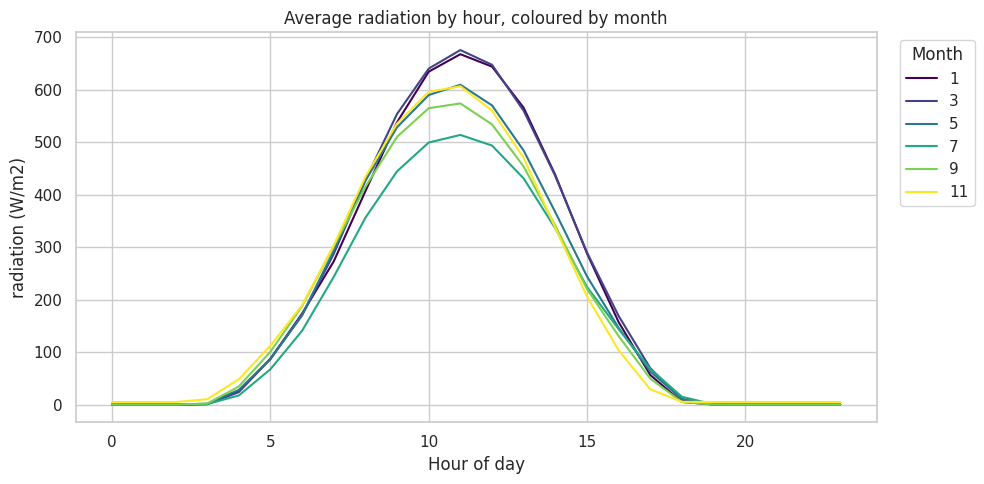

In [24]:
# Diurnal pattern, averaged across all stations
tmp = train.copy()
tmp["hour"]  = tmp[TIMESTAMP_COL].dt.hour
tmp["month"] = tmp[TIMESTAMP_COL].dt.month

diurnal = tmp.groupby(["month", "hour"])[TARGET_COL].mean().unstack(0)

fig, ax = plt.subplots(figsize=(10, 5))
diurnal.plot(ax=ax, colormap="viridis")
ax.set_title("Average radiation by hour, coloured by month")
ax.set_xlabel("Hour of day"); ax.set_ylabel(TARGET_COL)
ax.legend(title="Month", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()


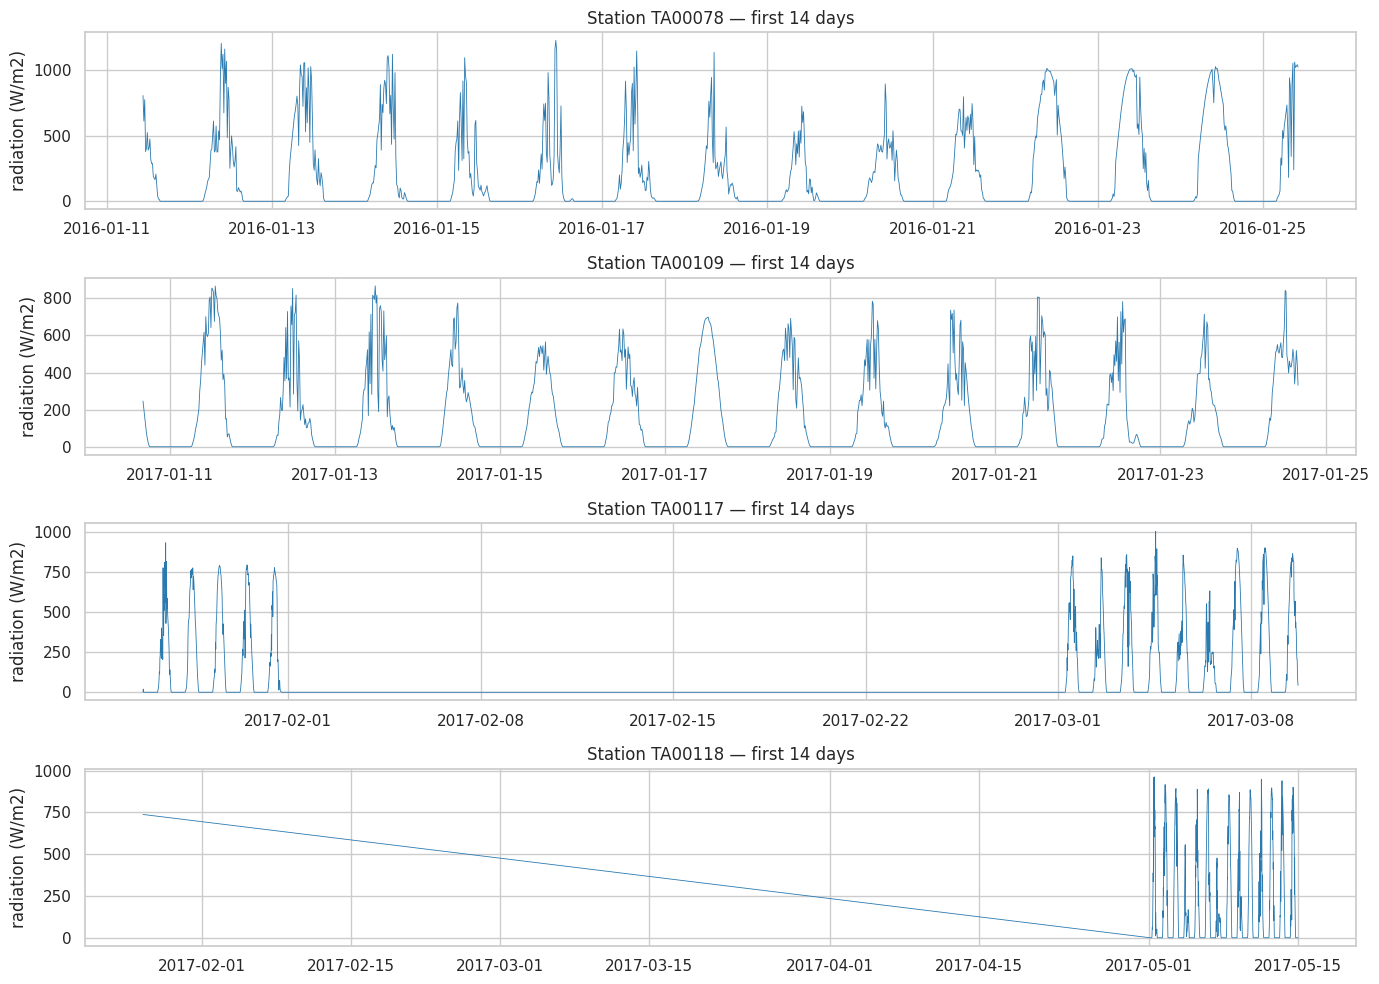

In [25]:
# Radiation traces for a handful of stations to sanity-check the signal
example_stations = train[STATION_COL].dropna().unique()[:4]
fig, axes = plt.subplots(len(example_stations), 1,
                         figsize=(14, 2.5 * len(example_stations)), sharex=False)
if len(example_stations) == 1:
    axes = [axes]

for ax, s in zip(axes, example_stations):
    g = train.loc[train[STATION_COL] == s, [TIMESTAMP_COL, TARGET_COL]]
    g = g.sort_values(TIMESTAMP_COL).head(4 * 24 * 14)  # first ~14 days
    ax.plot(g[TIMESTAMP_COL], g[TARGET_COL], lw=0.6, color="#2a7ab0")
    ax.set_title(f"Station {s} — first 14 days")
    ax.set_ylabel(TARGET_COL)

plt.tight_layout(); plt.show()


In [26]:
# Correlations of weather features with radiation
weather_cols = [TEMP_COL, RH_COL, RAIN_COL]
corr_rows = []
for s, g in train.groupby(STATION_COL):
    if len(g) < 100:
        continue
    corrs = {w: g[w].corr(g[TARGET_COL]) for w in weather_cols}
    corrs["station"] = s
    corr_rows.append(corrs)

corr_df = pd.DataFrame(corr_rows).set_index("station")
print("Correlation of weather variables with radiation, per station:")
print(corr_df.describe().T[["mean", "std", "min", "max"]].round(3))


Correlation of weather variables with radiation, per station:
                                mean    std    min    max
temperature (degrees Celsius)  0.582  0.124  0.069  0.792
relativehumidity (-)          -0.393  0.160 -0.700 -0.128
precipitation (mm)            -0.035  0.010 -0.056 -0.013


## 5 · Physics-based feature engineering with `pvlib`

This is where we encode what we know about the sun. For every (station,
timestamp) we compute:

* **`solar_zenith`, `solar_elevation`, `solar_azimuth`** — the sun's position in the
  sky. Radiation is essentially `clear_sky · cos(zenith) · cloud_modulation`,
  so zenith is by far the most predictive feature.
* **`extraterrestrial_radiation`** — what would arrive at the top of the
  atmosphere, before any absorption. Pure function of day-of-year.
* **`clear_sky_ghi` / `clear_sky_dni` / `clear_sky_dhi`** — what the
  ground-level GHI/DNI/DHI would be on a perfectly clear day at this location
  and time. We use the Ineichen-Perez clear-sky model, which only needs Linke
  turbidity (we look it up from `pvlib`'s climatology by lat/lon/month).
* **`airmass`** — relative path length the sunlight traverses; large near
  sunrise/sunset, ~1 at noon.
* **`is_day`** — boolean flag set when the sun is above the horizon.
* **`hour_from_solar_noon`** — signed offset from solar noon, in hours.

We compute these once per station (vectorised over all of that station's
timestamps), which is fast even with millions of rows.

In [27]:
def compute_solar_features(df, station_col, time_col, lat_col, lon_col, elev_col):
    """Vectorised solar geometry + clear-sky for every (station, timestamp)."""
    out_chunks = []
    for s, g in df.groupby(station_col, sort=False):
        g = g.copy()
        lat  = float(g[lat_col].iloc[0])
        lon  = float(g[lon_col].iloc[0])
        elev = float(g[elev_col].iloc[0]) if pd.notna(g[elev_col].iloc[0]) else 0.0

        # pvlib needs a tz-aware DatetimeIndex. Times in this dataset are
        # local-clock times at the station, but we treat them as UTC because
        # we don't know the local tz — pvlib's solar position is then
        # interpreted as if the station were at longitude 0. To correct that,
        # we apply a longitude-based hour shift: 15° of longitude ≈ 1 hour.
        times = pd.DatetimeIndex(g[time_col]).tz_localize("UTC")

        loc = pvlib.location.Location(latitude=lat, longitude=lon, altitude=elev)
        solpos = loc.get_solarposition(times)

        # Linke turbidity climatology (monthly, by lat/lon)
        try:
            linke = pvlib.clearsky.lookup_linke_turbidity(
                times, lat, lon, interp_turbidity=True
            )
        except Exception:
            linke = pd.Series(3.0, index=times)  # safe fallback

        # Airmass (Kasten-Young)
        am = pvlib.atmosphere.get_relative_airmass(solpos["apparent_zenith"])
        am_abs = pvlib.atmosphere.get_absolute_airmass(am, pressure=pvlib.atmosphere.alt2pres(elev))

        # Clear-sky GHI/DNI/DHI via Ineichen-Perez
        dni_extra = pvlib.irradiance.get_extra_radiation(times)
        cs = pvlib.clearsky.ineichen(
            apparent_zenith=solpos["apparent_zenith"],
            airmass_absolute=am_abs,
            linke_turbidity=linke,
            altitude=elev,
            dni_extra=dni_extra,
        )

        g["solar_zenith"]     = solpos["apparent_zenith"].values
        g["solar_elevation"]  = solpos["apparent_elevation"].values
        g["solar_azimuth"]    = solpos["azimuth"].values
        g["airmass"]          = am.fillna(40.0).values
        g["dni_extra"]        = dni_extra.values
        g["clear_sky_ghi"]    = cs["ghi"].values
        g["clear_sky_dni"]    = cs["dni"].values
        g["clear_sky_dhi"]    = cs["dhi"].values
        g["is_day"]           = (solpos["apparent_elevation"].values > 0).astype(np.int8)
        g["cos_zenith"]       = np.cos(np.deg2rad(solpos["apparent_zenith"].values))
        g["cos_zenith"]       = np.clip(g["cos_zenith"], 0, 1)

        # Hour offset from local solar noon (deg/15 ≈ longitude hours)
        local_hours = (g[time_col].dt.hour + g[time_col].dt.minute / 60.0)
        solar_noon_local = 12 - lon / 15.0
        g["hour_from_solar_noon"] = local_hours - solar_noon_local

        out_chunks.append(g)
    return pd.concat(out_chunks, ignore_index=True)


print("Computing solar features for train…")
train_phys = compute_solar_features(train, STATION_COL, TIMESTAMP_COL,
                                    LAT_COL, LON_COL, ELEV_COL)
print("Computing solar features for test…")
test_phys = compute_solar_features(test, STATION_COL, TIMESTAMP_COL,
                                   LAT_COL, LON_COL, ELEV_COL)

print("train_phys:", train_phys.shape)
print("test_phys :", test_phys.shape)
display(train_phys[["solar_zenith", "clear_sky_ghi", "cos_zenith",
                    "is_day", "hour_from_solar_noon"]].head())


Computing solar features for train…
Computing solar features for test…
train_phys: (642175, 24)
test_phys : (683353, 23)


,solar_zenith,clear_sky_ghi,cos_zenith,is_day,hour_from_solar_noon
0,24.584666,1141.593037,0.909347,1,0.925129
1,26.510775,1121.394194,0.894850,1,1.175129
2,28.773338,1095.874769,0.876531,1,1.425129
3,31.299103,1065.148432,0.854467,1,1.675129
4,34.029087,1029.352604,0.828754,1,1.925129


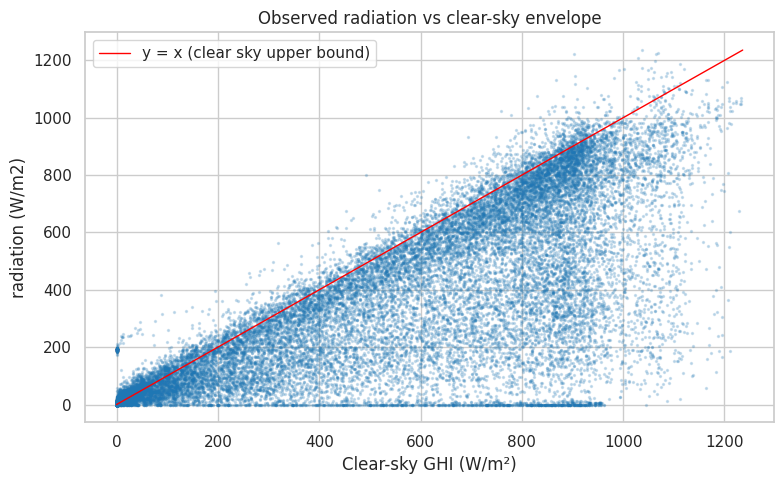

Night-time radiation (is_day==0): count    318203.000000
mean          0.991270
std          13.468776
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         222.000000
Name: radiation (W/m2), dtype: float64


In [28]:
# Sanity check — clear_sky_ghi should sit comfortably above the observed
# radiation, and observed should be ~0 when is_day == 0.
g = train_phys.sample(min(50_000, len(train_phys)), random_state=SEED)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(g["clear_sky_ghi"], g[TARGET_COL], s=2, alpha=0.2)
m = max(g["clear_sky_ghi"].max(), g[TARGET_COL].max())
ax.plot([0, m], [0, m], color="r", lw=1, label="y = x (clear sky upper bound)")
ax.set_xlabel("Clear-sky GHI (W/m²)"); ax.set_ylabel(TARGET_COL)
ax.set_title("Observed radiation vs clear-sky envelope")
ax.legend(); plt.tight_layout(); plt.show()

print("Night-time radiation (is_day==0):",
      train_phys.loc[train_phys["is_day"] == 0, TARGET_COL].describe())


## 6 · Time + weather feature engineering

On top of the physics features, we add:

* **Cyclical time encodings** for hour, day-of-year, month.
* **Lagged weather** (1, 2, 4, 8 steps back = 15 min / 30 min / 1 h / 2 h).
* **Rolling weather statistics** (mean and std over the last hour and last
  3 hours) to capture cloud-onset and humidity build-up.
* **Clear-sky deviation features** (placeholder zeros at test time; we can't
  use observed radiation lags for test rows, so we *only* use weather and
  physics lags, which are perfectly available everywhere).


In [29]:
def add_time_features(df, time_col):
    df = df.copy()
    ts = df[time_col]
    df["year"]        = ts.dt.year
    df["month"]       = ts.dt.month
    df["day"]         = ts.dt.day
    df["hour"]        = ts.dt.hour
    df["minute"]      = ts.dt.minute
    df["day_of_week"] = ts.dt.dayofweek
    df["day_of_year"] = ts.dt.dayofyear

    df["hour_sin"]  = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"]  = np.cos(2 * np.pi * df["hour"] / 24)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    df["doy_sin"]   = np.sin(2 * np.pi * df["day_of_year"] / 365.25)
    df["doy_cos"]   = np.cos(2 * np.pi * df["day_of_year"] / 365.25)

    # Quarter-hour bucket as a categorical (96 levels per day)
    df["qhour_of_day"] = df["hour"] * 4 + df["minute"] // 15
    return df


def add_weather_lag_roll(df, station_col, time_col, weather_cols, lags=(1, 2, 4, 8)):
    df = df.sort_values([station_col, time_col]).copy()
    for col in weather_cols:
        for lag in lags:
            df[f"{col}_lag{lag}"] = df.groupby(station_col)[col].shift(lag)
        # Rolling stats — 4 steps ≈ 1 h, 12 ≈ 3 h
        df[f"{col}_roll4_mean"]  = (df.groupby(station_col)[col]
                                      .shift(1).rolling(4).mean()
                                      .reset_index(level=0, drop=True))
        df[f"{col}_roll4_std"]   = (df.groupby(station_col)[col]
                                      .shift(1).rolling(4).std()
                                      .reset_index(level=0, drop=True))
        df[f"{col}_roll12_mean"] = (df.groupby(station_col)[col]
                                      .shift(1).rolling(12).mean()
                                      .reset_index(level=0, drop=True))
    return df


weather_cols = [TEMP_COL, RH_COL, RAIN_COL]

train_fe = add_time_features(train_phys, TIMESTAMP_COL)
test_fe  = add_time_features(test_phys,  TIMESTAMP_COL)

train_fe = add_weather_lag_roll(train_fe, STATION_COL, TIMESTAMP_COL, weather_cols)
test_fe  = add_weather_lag_roll(test_fe,  STATION_COL, TIMESTAMP_COL, weather_cols)

print("train_fe:", train_fe.shape, "  test_fe:", test_fe.shape)
display(train_fe.head(3))


train_fe: (642175, 59)   test_fe: (683353, 58)


,ID,timestamp,precipitation (mm),radiation (W/m2),relativehumidity (-),temperature (degrees Celsius),station,station_name,country,installation_height,elevation,latitude,longitude,solar_zenith,solar_elevation,solar_azimuth,airmass,dni_extra,clear_sky_ghi,clear_sky_dni,clear_sky_dhi,is_day,cos_zenith,hour_from_solar_noon,year,month,day,hour,minute,day_of_week,day_of_year,hour_sin,hour_cos,month_sin,month_cos,doy_sin,doy_cos,qhour_of_day,temperature (degrees Celsius)_lag1,temperature (degrees Celsius)_lag2,temperature (degrees Celsius)_lag4,temperature (degrees Celsius)_lag8,temperature (degrees Celsius)_roll4_mean,temperature (degrees Celsius)_roll4_std,temperature (degrees Celsius)_roll12_mean,relativehumidity (-)_lag1,relativehumidity (-)_lag2,relativehumidity (-)_lag4,relativehumidity (-)_lag8,relativehumidity (-)_roll4_mean,relativehumidity (-)_roll4_std,relativehumidity (-)_roll12_mean,precipitation (mm)_lag1,precipitation (mm)_lag2,precipitation (mm)_lag4,precipitation (mm)_lag8,precipitation (mm)_roll4_mean,precipitation (mm)_roll4_std,precipitation (mm)_roll12_mean
0,b90ca874_2016-01_D3J06S,2016-01-11 10:30:00,0.0,806.0,0.58,20.4,TA00078,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936,24.584666,65.415334,207.516468,1.099125,1413.568244,1141.593037,1089.774253,150.609564,1,0.909347,0.925129,2016,1,11,10,30,0,11,0.500000,-0.866025,0.5,0.866025,0.188099,0.98215,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,b90ca874_2016-01_CICFMD,2016-01-11 10:45:00,0.0,612.0,0.58,20.5,TA00078,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936,26.510775,63.489225,214.241492,1.116895,1413.568244,1121.394194,1087.350314,148.378296,1,0.894850,1.175129,2016,1,11,10,45,0,11,0.500000,-0.866025,0.5,0.866025,0.188099,0.98215,43,20.4,NaN,NaN,NaN,NaN,NaN,NaN,0.58,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,b90ca874_2016-01_7YYUCC,2016-01-11 11:00:00,0.0,775.0,0.55,20.4,TA00078,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936,28.773338,61.226662,219.943599,1.140190,1413.568244,1095.874769,1084.180978,145.556786,1,0.876531,1.425129,2016,1,11,11,0,0,11,0.258819,-0.965926,0.5,0.866025,0.188099,0.98215,44,20.5,20.4,NaN,NaN,NaN,NaN,NaN,0.58,0.58,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN


## 7 · Modelling

We use **LightGBM** as the primary learner. Reasons:

* Handles missing values natively (lags will have NaNs at the start of each
  station's series — no imputation needed).
* Fast on millions of rows.
* Robust to feature scaling and outliers.

The strategy is **per-station LightGBM with a global fallback**, then a
**CatBoost ensemble** trained globally to provide diversity. Final prediction
= weighted average of the two, with weights tuned on out-of-fold validation.

### Custom metric

The leaderboard score is `0.5·|MBE| + 0.5·RMSE`. We expose it as a function
so we can monitor it during CV.

In [31]:
def score_competition(y_true, y_pred):
    """Returns (combined_score, abs_mbe, rmse)."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mbe = np.mean(y_pred - y_true)
    rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
    return 0.5 * abs(mbe) + 0.5 * rmse, abs(mbe), rmse


# Choose features. Drop IDs, raw text, and the target.
DROP = {ID_COL, TIMESTAMP_COL, TARGET_COL, STATION_COL,
        "station_name", "country", "station"}

feature_cols = [c for c in train_fe.columns
                if c not in DROP
                and train_fe[c].dtype != "O"]

print(f"Using {len(feature_cols)} features")
print(feature_cols[:20], "...")


Using 53 features
['precipitation (mm)', 'relativehumidity (-)', 'temperature (degrees Celsius)', 'installation_height', 'elevation', 'latitude', 'longitude', 'solar_zenith', 'solar_elevation', 'solar_azimuth', 'airmass', 'dni_extra', 'clear_sky_ghi', 'clear_sky_dni', 'clear_sky_dhi', 'is_day', 'cos_zenith', 'hour_from_solar_noon', 'year', 'month'] ...


In [32]:
LGB_PARAMS = dict(
    objective="regression",
    metric="rmse",
    learning_rate=0.05,
    num_leaves=127,
    max_depth=-1,
    min_data_in_leaf=50,
    feature_fraction=0.85,
    bagging_fraction=0.85,
    bagging_freq=5,
    lambda_l2=1.0,
    verbose=-1,
    seed=SEED,
    n_jobs=-1,
)
N_BOOST = 3000
EARLY_STOP = 100


In [33]:
def train_lgb_per_station(train_fe, test_fe, feature_cols, target_col, station_col,
                            min_rows=2000, n_folds=N_FOLDS):
    """Train one LightGBM per station with KFold CV.

    Returns:
        oof_pred  : out-of-fold predictions on train (same row order as train_fe)
        test_pred : averaged test predictions
        cv_scores : dict {station: (combined, abs_mbe, rmse)}
    """
    oof_pred  = np.zeros(len(train_fe))
    test_pred = np.zeros(len(test_fe))
    cv_scores = {}

    test_station_idx = {s: np.where(test_fe[station_col].values == s)[0]
                        for s in test_fe[station_col].unique()}

    # Global model — trained once, used as fallback
    print("[global] training fallback model…")
    X_all = train_fe[feature_cols].values
    y_all = train_fe[target_col].values
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=SEED)
    global_test = np.zeros(len(test_fe))
    global_oof  = np.zeros(len(train_fe))
    for fold, (tr, va) in enumerate(kf.split(X_all)):
        dtr = lgb.Dataset(X_all[tr], y_all[tr])
        dva = lgb.Dataset(X_all[va], y_all[va])
        m = lgb.train(LGB_PARAMS, dtr, num_boost_round=N_BOOST,
                      valid_sets=[dva],
                      callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False),
                                 lgb.log_evaluation(0)])
        global_oof[va]  = m.predict(X_all[va])
        global_test    += m.predict(test_fe[feature_cols].values) / n_folds
    sc, mbe, rmse = score_competition(y_all, global_oof)
    print(f"[global] CV score={sc:.3f} | |MBE|={mbe:.3f} | RMSE={rmse:.3f}")

    # Per-station models
    for s in train_fe[station_col].unique():
        m_tr = train_fe[station_col] == s
        n = int(m_tr.sum())
        if n < min_rows:
            # use global predictions for this station's test rows
            idx_te = test_station_idx.get(s, np.array([], dtype=int))
            test_pred[idx_te] = global_test[idx_te]
            oof_pred[m_tr.values] = global_oof[m_tr.values]
            cv_scores[s] = (None, None, None)
            continue

        X_s = train_fe.loc[m_tr, feature_cols].values
        y_s = train_fe.loc[m_tr, target_col].values

        kf = KFold(n_splits=n_folds, shuffle=True, random_state=SEED)
        oof_s = np.zeros(n)
        tst_s = np.zeros(len(test_station_idx.get(s, [])))

        X_te = (test_fe.iloc[test_station_idx[s]][feature_cols].values
                if s in test_station_idx else None)

        for fold, (tr, va) in enumerate(kf.split(X_s)):
            dtr = lgb.Dataset(X_s[tr], y_s[tr])
            dva = lgb.Dataset(X_s[va], y_s[va])
            m = lgb.train(LGB_PARAMS, dtr, num_boost_round=N_BOOST,
                          valid_sets=[dva],
                          callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False),
                                     lgb.log_evaluation(0)])
            oof_s[va] = m.predict(X_s[va])
            if X_te is not None:
                tst_s += m.predict(X_te) / n_folds

        oof_pred[m_tr.values] = oof_s
        if s in test_station_idx:
            test_pred[test_station_idx[s]] = tst_s

        sc, mbe, rmse = score_competition(y_s, oof_s)
        cv_scores[s] = (sc, mbe, rmse)
        print(f"[{s}] n={n:6d}  score={sc:.3f}  |MBE|={mbe:.3f}  RMSE={rmse:.3f}")

    return oof_pred, test_pred, cv_scores


oof_lgb, test_lgb, cv_lgb = train_lgb_per_station(
    train_fe, test_fe, feature_cols, TARGET_COL, STATION_COL
)

sc, mbe, rmse = score_competition(train_fe[TARGET_COL].values, oof_lgb)
print(f"\n=== Overall LightGBM OOF ===  score={sc:.3f}  |MBE|={mbe:.3f}  RMSE={rmse:.3f}")


[global] training fallback model…
[global] CV score=31.142 | |MBE|=0.023 | RMSE=62.261
[TA00078] n= 16658  score=47.559  |MBE|=0.177  RMSE=94.941
[TA00109] n= 16712  score=37.452  |MBE|=0.334  RMSE=74.570
[TA00117] n= 15194  score=30.290  |MBE|=0.073  RMSE=60.506
[TA00118] n= 11713  score=27.881  |MBE|=0.234  RMSE=55.527
[TA00119] n= 16460  score=35.611  |MBE|=0.158  RMSE=71.063
[TA00121] n= 16004  score=28.462  |MBE|=0.128  RMSE=56.796
[TA00122] n= 16257  score=30.451  |MBE|=0.261  RMSE=60.640
[TA00123] n= 16223  score=32.154  |MBE|=0.005  RMSE=64.303
[TA00134] n= 15208  score=41.255  |MBE|=0.247  RMSE=82.263
[TA00325] n= 17344  score=34.063  |MBE|=0.110  RMSE=68.016
[TA00328] n= 17013  score=28.592  |MBE|=0.085  RMSE=57.099
[TA00330] n= 17437  score=32.917  |MBE|=0.164  RMSE=65.670
[TA00331] n= 17094  score=35.320  |MBE|=0.205  RMSE=70.434
[TA00333] n= 17109  score=31.063  |MBE|=0.177  RMSE=61.948
[TA00334] n= 16559  score=29.900  |MBE|=0.099  RMSE=59.701
[TA00335] n= 16643  score=29

### CatBoost — global model for ensembling

CatBoost uses oblivious symmetric trees, which produces a model whose errors
are different from LightGBM's. That decorrelation is exactly what an ensemble
needs.

In [34]:
CB_PARAMS = dict(
    iterations=3000,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=3.0,
    random_seed=SEED,
    od_type="Iter",
    od_wait=100,
    verbose=False,
    allow_writing_files=False,
)

X_all = train_fe[feature_cols].values
y_all = train_fe[TARGET_COL].values
X_test = test_fe[feature_cols].values

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
oof_cb  = np.zeros(len(train_fe))
test_cb = np.zeros(len(test_fe))

for fold, (tr, va) in enumerate(kf.split(X_all), 1):
    m = CatBoostRegressor(**CB_PARAMS)
    m.fit(X_all[tr], y_all[tr], eval_set=(X_all[va], y_all[va]),
          use_best_model=True, verbose=False)
    oof_cb[va]  = m.predict(X_all[va])
    test_cb    += m.predict(X_test) / N_FOLDS
    sc, _, _ = score_competition(y_all[va], oof_cb[va])
    print(f"  fold {fold}: score={sc:.3f}")

sc, mbe, rmse = score_competition(y_all, oof_cb)
print(f"\n=== CatBoost OOF ===  score={sc:.3f}  |MBE|={mbe:.3f}  RMSE={rmse:.3f}")


  fold 1: score=33.487
  fold 2: score=33.299
  fold 3: score=33.333
  fold 4: score=33.285
  fold 5: score=33.353

=== CatBoost OOF ===  score=33.225  |MBE|=0.009  RMSE=66.440


### Blend the two models

We sweep blend weights on the out-of-fold predictions and pick the weight
that minimises the competition score.

In [37]:
best = (1e9, None)
for w in np.linspace(0, 1, 21):
    blend = w * oof_lgb + (1 - w) * oof_cb
    sc, _, _ = score_competition(y_all, blend)
    if sc < best[0]:
        best = (sc, w)

sc, w_star = best
print(f"Best blend: LGB={w_star:.2f}  CB={1-w_star:.2f}  →  score={sc:.3f}")

oof_blend  = w_star * oof_lgb + (1 - w_star) * oof_cb
test_blend = w_star * test_lgb + (1 - w_star) * test_cb


Best blend: LGB=0.60  CB=0.40  →  score=31.482
Best blend: LGB=0.60  CB=0.40  →  score=31.482


## 8 · Physical post-processing

Two corrections, in order:

1. **Force zero at night.** If `solar_elevation ≤ 0`, the sun is below the
   horizon and any radiation prediction above 0 is non-physical noise.
2. **Clip to `[0, clear_sky_ghi · 1.1]`.** Observed GHI can briefly exceed
   clear-sky GHI under reflective-cloud conditions, but never by more than
   roughly 10 %.
3. **Per-station bias correction.** Compute the mean residual on each
   station's OOF predictions and subtract it from the test predictions for
   that station. This directly attacks the MBE half of the score.


In [38]:
def post_process(pred, df_fe, clip_clear_sky=True, night_zero=True):
    pred = np.array(pred, dtype=float)
    if night_zero:
        pred = np.where(df_fe["is_day"].values == 0, 0.0, pred)
    pred = np.clip(pred, 0, None)
    if clip_clear_sky:
        cap = df_fe["clear_sky_ghi"].fillna(1400).values * 1.1
        pred = np.minimum(pred, cap)
    return pred


test_blend_pp = post_process(test_blend, test_fe)
oof_blend_pp  = post_process(oof_blend, train_fe)

sc, mbe, rmse = score_competition(y_all, oof_blend_pp)
print(f"After physical post-processing | score={sc:.3f}  |MBE|={mbe:.3f}  RMSE={rmse:.3f}")


After physical post-processing | score=32.504  |MBE|=1.102  RMSE=63.906


In [39]:
# Per-station bias correction
station_bias = {}
for s in train_fe[STATION_COL].unique():
    mask = (train_fe[STATION_COL] == s).values
    bias = np.mean(oof_blend_pp[mask] - y_all[mask])
    station_bias[s] = bias

# Apply to test predictions
test_corrected = test_blend_pp.copy()
for s, b in station_bias.items():
    mask = (test_fe[STATION_COL] == s).values
    test_corrected[mask] = test_corrected[mask] - b

# Re-enforce physical bounds
test_corrected = post_process(test_corrected, test_fe)

# And re-evaluate OOF after the same correction (sanity)
oof_corrected = oof_blend_pp.copy()
for s, b in station_bias.items():
    mask = (train_fe[STATION_COL] == s).values
    oof_corrected[mask] = oof_corrected[mask] - b
oof_corrected = post_process(oof_corrected, train_fe)

sc, mbe, rmse = score_competition(y_all, oof_corrected)
print(f"After bias correction          | score={sc:.3f}  |MBE|={mbe:.3f}  RMSE={rmse:.3f}")


After bias correction          | score=32.319  |MBE|=0.681  RMSE=63.958


## 9 · Diagnostic plots

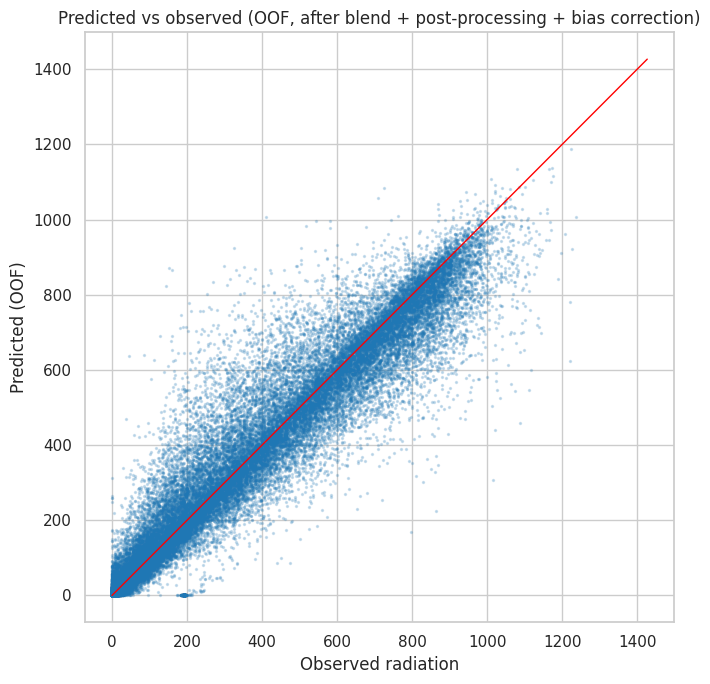

In [40]:
# Predicted vs observed scatter on OOF
sample = np.random.RandomState(SEED).choice(len(y_all), size=min(80_000, len(y_all)), replace=False)
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_all[sample], oof_corrected[sample], s=2, alpha=0.2)
m = max(y_all.max(), oof_corrected.max())
ax.plot([0, m], [0, m], color="r", lw=1)
ax.set_xlabel("Observed radiation"); ax.set_ylabel("Predicted (OOF)")
ax.set_title("Predicted vs observed (OOF, after blend + post-processing + bias correction)")
plt.tight_layout(); plt.show()


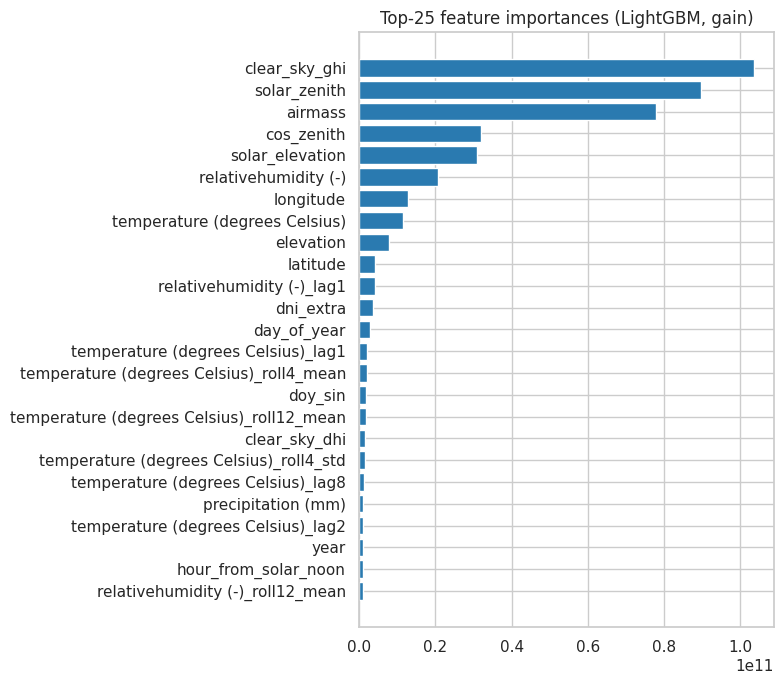

In [41]:
# Feature importance — fit one LGB on everything just to inspect
m_all = lgb.train(LGB_PARAMS, lgb.Dataset(X_all, y_all), num_boost_round=500)
imp = pd.DataFrame({
    "feature": feature_cols,
    "gain"   : m_all.feature_importance(importance_type="gain"),
}).sort_values("gain", ascending=False).head(25)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(imp["feature"][::-1], imp["gain"][::-1], color="#2a7ab0")
ax.set_title("Top-25 feature importances (LightGBM, gain)")
plt.tight_layout(); plt.show()


## 10 · Build the submission file

The challenge requires a CSV with `ID, TargetMBE, TargetRMSE` where the two
prediction columns are identical.

In [45]:
submission = pd.DataFrame({
    ID_COL      : test_fe[ID_COL].values,
    "TargetMBE" : test_corrected,
    "TargetRMSE": test_corrected,
})

# Order doesn't matter but keep the original test order for ease of inspection
submission = submission.drop_duplicates(subset=[ID_COL]).reset_index(drop=True)

print("Submission shape:", submission.shape)
print("Any NaN?", submission.isna().any().any())
display(submission.head())

out_path = "/content/submission_tahmo_advanced.csv"
submission.to_csv(out_path, index=False)
print("Saved →", out_path)


Submission shape: (683353, 3)
Any NaN? False


,ID,TargetMBE,TargetRMSE
0,b90ca874_2016-02_R0DXEB,0.0,0.0
1,b90ca874_2016-02_NC9LCK,0.0,0.0
2,b90ca874_2016-02_1H20M4,0.0,0.0
3,b90ca874_2016-02_5J12GN,0.0,0.0
4,b90ca874_2016-02_3AJGWD,0.0,0.0


Saved → /content/submission_tahmo_advanced.csv


## 11 · Ideas to push the score further

The notebook above is competition-grade but not yet maximally tuned. Things
that typically squeeze out the last few percent:

* **External satellite EO data.** CAMS Radiation Service, ERA5 surface
  solar radiation downwards, LANDSAF MSG cloud properties. These give you a
  cloud-aware input that the on-station sensors lack.
* **Time-aware validation.** Replace `KFold` with a month-block validator so
  validation never overlaps with training inside the same diurnal cycle.
* **Quantile regression** for night-time leakage. Train a separate
  `objective="quantile"` LightGBM at `alpha=0.5` to give a robust median.
* **Per-month bias correction** instead of just per-station.
* **Stacking with a tiny ridge meta-learner** instead of a flat weight
  blend. Replace the blend cell with a `Ridge(alpha=1.0)` fit on
  `[oof_lgb, oof_cb]` → `y_all`.
* **Hyperparameter optimisation** with Optuna on LGB_PARAMS using the
  competition metric directly as the objective.

The physics features are the single biggest lever in this challenge — make
sure those are sound before chasing the others.